# Exploration Data Analysis
A telecom company want to build a machine learning model to know whether the customer will leave or stay. Inorder to determine, company data will be cleaning and pipelined to the ML model. The output of the ML model will be the prediction of whether the customer churn or not.

### Dataset
The kaggle dataset is been used for the building the model [Kaggle](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset)

### AIM

Explore the dataset and provide the analysis about the data and step to build the data cleaning pipleline.

### Import Packages

In [1]:
import math
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Load the raw dataset from `raw_data/`.

In [2]:
ROOT = pathlib.Path.cwd()
ROOT = ROOT.parent if ROOT.name == "notebook" else ROOT

df = pd.read_excel(ROOT / "raw_data" / "Telco_customer_churn.xlsx")

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

### Target variable — class balance

Before looking at any feature, quantify how (im)balanced `Churn Value` is. This decides the
train/test split strategy (stratify), the evaluation metric (PR-AUC / recall over accuracy),
and whether class weighting or resampling is needed.

Churn Value
0    5174
1    1869
Name: count, dtype: int64

Overall churn rate : 26.5%
Class ratio (stay:churn): 2.77 : 1


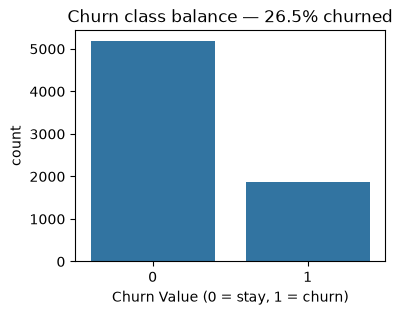

In [5]:
# --- Target variable: class balance ---
churn_counts = df['Churn Value'].value_counts().sort_index()
churn_rate = df['Churn Value'].mean()

print(churn_counts)
print(f"\nOverall churn rate : {churn_rate:.1%}")
print(f"Class ratio (stay:churn): {churn_counts[0] / churn_counts[1]:.2f} : 1")

plt.figure(figsize=(4, 3))
sns.countplot(x=df['Churn Value'])
plt.title(f'Churn class balance — {churn_rate:.1%} churned')
plt.xlabel('Churn Value (0 = stay, 1 = churn)')
plt.show()

### Descriptive statistics

Full numeric and categorical summaries — value ranges, spread, and the dominant category per
object column. Surfaces unexpected values before any feature-level analysis.

In [6]:
# Numeric columns — range and spread
print(df.describe().T)

# Categorical columns — cardinality, most frequent value and its share
print()
print(df.describe(include='object').T)

                  count          mean          std           min  \
Count            7043.0      1.000000     0.000000      1.000000   
Zip Code         7043.0  93521.964646  1865.794555  90001.000000   
Latitude         7043.0     36.282441     2.455723     32.555828   
Longitude        7043.0   -119.798880     2.157889   -124.301372   
Tenure Months    7043.0     32.371149    24.559481      0.000000   
Monthly Charges  7043.0     64.761692    30.090047     18.250000   
Churn Value      7043.0      0.265370     0.441561      0.000000   
Churn Score      7043.0     58.699418    21.525131      5.000000   
CLTV             7043.0   4400.295755  1183.057152   2003.000000   

                          25%           50%           75%           max  
Count                1.000000      1.000000      1.000000      1.000000  
Zip Code         92102.000000  93552.000000  95351.000000  96161.000000  
Latitude            34.030915     36.391777     38.224869     41.962127  
Longitude         -121.

/var/folders/0g/3sxqhwdj7w11cq_1lmzdy8yh0000gn/T/ipykernel_98765/969151113.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include='object').T)


### Data quality — duplicates, key uniqueness, missing values

Check row-level duplication, that `CustomerID` is a valid primary key, and where values are missing
(rather than handling missingness ad hoc later).

In [7]:
# --- Row-level integrity ---
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated CustomerID :", df['CustomerID'].duplicated().sum())
print("CustomerID is a valid key:", df['CustomerID'].is_unique)

# --- Missing values (only columns that have any) ---
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("\nColumns with missing values:")
print(missing if not missing.empty else "none")

# Churn Reason should be null for exactly the customers who did not churn
reason_matches_target = (df['Churn Reason'].isna() == (df['Churn Value'] == 0)).all()
print("\nChurn Reason is null iff customer did not churn:", reason_matches_target)

# Total Charges is stored as text — count rows that will not parse as a number
non_numeric_total = pd.to_numeric(df['Total Charges'], errors='coerce').isna().sum()
print("Total Charges rows not parseable as numeric:", non_numeric_total)

Fully duplicated rows: 0
Duplicated CustomerID : 0
CustomerID is a valid key: True

Columns with missing values:
Churn Reason    5174
dtype: int64

Churn Reason is null iff customer did not churn: True
Total Charges rows not parseable as numeric: 11


In [8]:
# Find all constant (zero-variance) columns
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(constant_cols)

['Count', 'Country', 'State']


**Observation:** Feature with one unique value across all the row has zero variance, which means no prediction power. Adding dead weights that just adds noise to the feature matrix and increase computation cost.

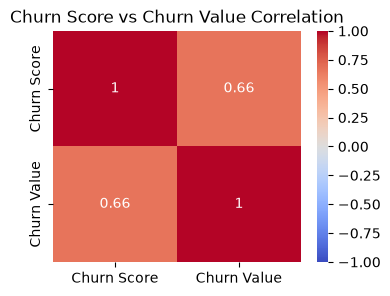

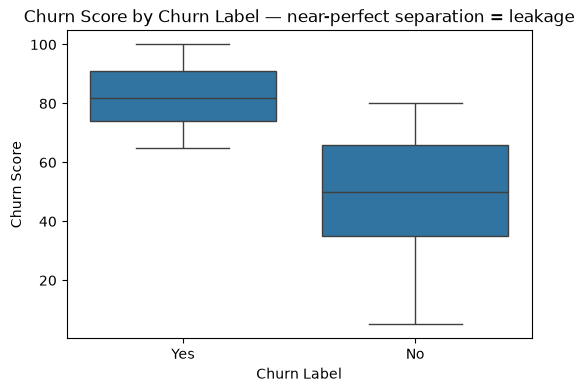

Churn Label                                Yes
Churn Reason                                  
Attitude of service provider               135
Attitude of support person                 192
Competitor had better devices              130
Competitor made better offer               140
Competitor offered higher download speeds  189
Competitor offered more data               162
Deceased                                     6
Don't know                                 154
Extra data charges                          57
Lack of affordable download/upload speed    44
Lack of self-service on Website             88
Limited range of services                   44
Long distance charges                       44
Moved                                       53
Network reliability                        103
Poor expertise of online support            19
Poor expertise of phone support             20
Price too high                              98
Product dissatisfaction                    102
Service dissa

In [9]:
# 1. Churn Score vs Churn Value (numeric-numeric) — correlation heatmap works directly
plt.figure(figsize=(4, 3))
sns.heatmap(df[['Churn Score', 'Churn Value']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Churn Score vs Churn Value Correlation')
plt.show()

# 2. Churn Score distribution split by Churn Label — shows the score is basically a proxy for the label
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn Label', y='Churn Score')
plt.title('Churn Score by Churn Label — near-perfect separation = leakage')
plt.show()

# 3. Churn Reason vs Churn Label — crosstab, since Reason only exists for churned customers
reason_crosstab = pd.crosstab(df['Churn Reason'], df['Churn Label'])
print(reason_crosstab)

**Observation:** The Churn value, label, score are inter-related and leads to data leak in the model training.

In [10]:
# Exclude constant cols + leakage cols + IDs (not useful visually)
exclude = constant_cols + ['Churn Score', 'Churn Reason', 'CustomerID', 'Churn Label']
plot_cols = [c for c in df.columns if c not in exclude]

# Split numeric vs categorical
numeric_cols = df[plot_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df[plot_cols].select_dtypes(include=['object']).columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

Numeric: ['Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Churn Value', 'CLTV']
Categorical: ['City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Total Charges']


/var/folders/0g/3sxqhwdj7w11cq_1lmzdy8yh0000gn/T/ipykernel_98765/1464536149.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df[plot_cols].select_dtypes(include=['object']).columns.tolist()


## Visualize data spread

In [11]:
# Separate categorical into plottable (low cardinality) vs skip (high cardinality)
CARDINALITY_THRESHOLD = 10
plottable_cat = [c for c in categorical_cols if df[c].nunique() <= CARDINALITY_THRESHOLD]
skipped_cat = [c for c in categorical_cols if df[c].nunique() > CARDINALITY_THRESHOLD]

print("Plotting categorical:", plottable_cat)
print("Skipping (high cardinality):", skipped_cat)

Plotting categorical: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Skipping (high cardinality): ['City', 'Lat Long', 'Total Charges']


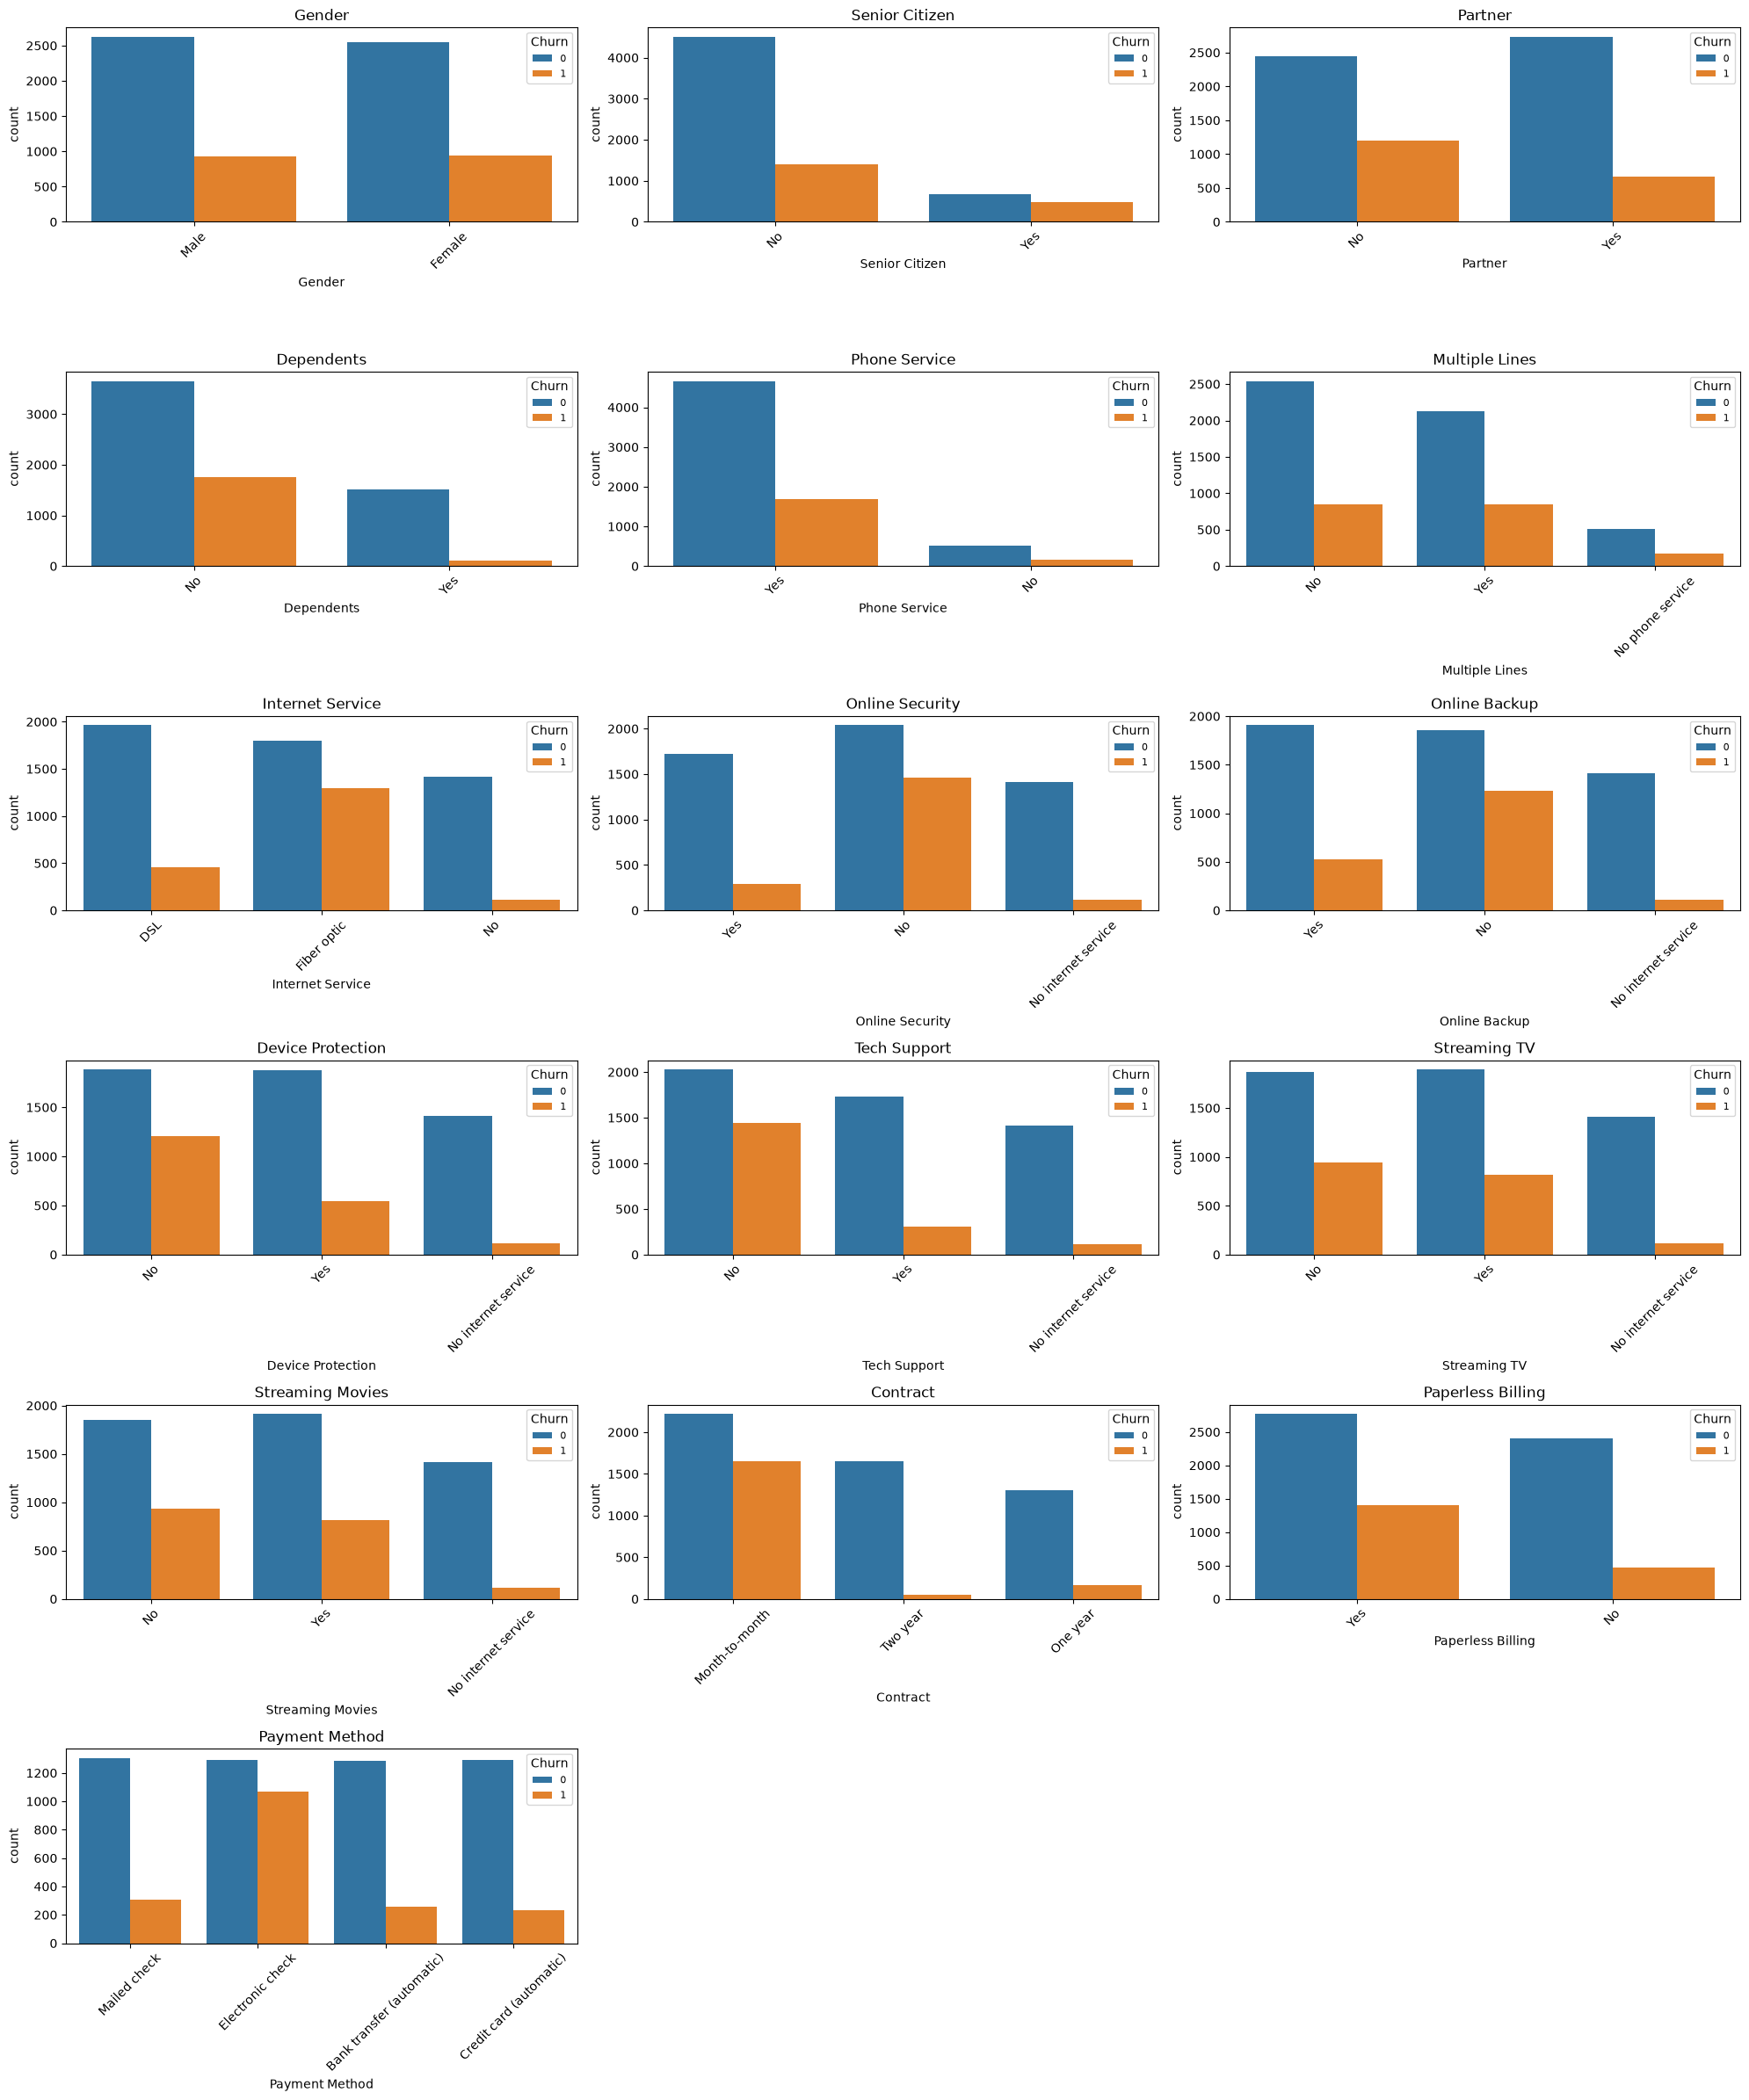

In [12]:
categorical_to_plot = ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
                        'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup',
                        'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
                        'Contract', 'Paperless Billing', 'Payment Method']

cols = 3
rows = math.ceil(len(categorical_to_plot) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_to_plot):
    sns.countplot(data=df, x=col, hue='Churn Value', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn', fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Graph observations (count plots split by Churn Value)

- **Contract**: Cleanest signal in the dataset. Month-to-month has by far the highest churn volume; 
  Two-year shows almost no churn (thin orange sliver). Monotonic relationship — churn drops sharply 
  as contract length increases.
- **Internet Service**: Fiber optic shows a visibly higher churn proportion than DSL, despite being 
  the "better" tech — likely tied to price rather than service quality (cross-check against Monthly Charges).
- **Payment Method**: Electronic check stands out with a visibly larger churn share than the other 
  three methods, which look roughly similar to each other.
- **Partner / Dependents**: Customers with No partner / No dependents show consistently higher churn — 
  likely tied to lower switching cost (no shared household service to coordinate).
- **Online Security / Tech Support**: "No" customers churn much more than "Yes" customers. Possible 
  confound with tenure (new customers haven't opted into add-ons yet) — don't over-claim causality.
- **Gender / Phone Service**: Visually near-identical bar proportions across categories — no apparent signal.
- **Structural pattern**: Online Security, Online Backup, Device Protection, Tech Support, Streaming TV, 
  Streaming Movies all carry a third category "No internet service" — this is fully determined by 
  Internet Service == 'No', not an independent signal. Same for Multiple Lines' "No phone service", 
  tied to Phone Service. Flagged for encoding-time cleanup (collapse into "No" to avoid redundant/
  correlated dummy columns).

In [13]:
# Churn RATE per category, not raw count
for col in categorical_to_plot:
    rate = df.groupby(col)['Churn Value'].mean().sort_values(ascending=False)
    print(f"\n{col}:\n{rate}")


Gender:
Gender
Female    0.269209
Male      0.261603
Name: Churn Value, dtype: float64

Senior Citizen:
Senior Citizen
Yes    0.416813
No     0.236062
Name: Churn Value, dtype: float64

Partner:
Partner
No     0.329580
Yes    0.196649
Name: Churn Value, dtype: float64

Dependents:
Dependents
No     0.325517
Yes    0.065151
Name: Churn Value, dtype: float64

Phone Service:
Phone Service
Yes    0.267096
No     0.249267
Name: Churn Value, dtype: float64

Multiple Lines:
Multiple Lines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn Value, dtype: float64

Internet Service:
Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn Value, dtype: float64

Online Security:
Online Security
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn Value, dtype: float64

Online Backup:
Online Backup
No                     0.399288
Yes                    

### Feature strength ranking (churn rate spread across categories)

**Strong (>20pt spread):** Contract, Payment Method, Internet Service, Online Security, Tech Support, 
Online Backup, Device Protection, Dependents, Senior Citizen

**Moderate (10–20pt spread):** Partner, Paperless Billing

**Weak / near-noise (<5pt spread):** Gender, Phone Service, Multiple Lines, Streaming TV, Streaming Movies

### Statistical test — categorical features vs churn

The strong / moderate / weak grouping above is eyeballed from churn-rate spread. Confirm it with a
chi-square test of independence (is the association real?) and Cramér's V (how strong is it, 0–1),
so the ranking is defensible and not just visual.

In [14]:
def cramers_v(contingency):
    """Effect size (0-1) for a categorical-categorical association."""
    chi2 = stats.chi2_contingency(contingency)[0]
    n = contingency.to_numpy().sum()
    min_dim = min(contingency.shape) - 1
    return np.sqrt((chi2 / n) / min_dim) if min_dim else np.nan


def test_feature(col):
    table = pd.crosstab(df[col], df['Churn Value'])
    chi2, p_value, _, _ = stats.chi2_contingency(table)
    return {'feature': col, 'chi2': chi2, 'p_value': p_value, 'cramers_v': cramers_v(table)}


chi2_results = pd.DataFrame(test_feature(c) for c in categorical_to_plot)
chi2_results = chi2_results.sort_values('cramers_v', ascending=False).reset_index(drop=True)
print(chi2_results.to_string(index=False))

          feature        chi2       p_value  cramers_v
         Contract 1184.596572 5.863038e-258   0.410116
  Online Security  849.998968 2.661150e-185   0.347400
     Tech Support  828.197068 1.443084e-180   0.342916
 Internet Service  732.309590 9.571788e-160   0.322455
   Payment Method  648.142327 3.682355e-140   0.303359
    Online Backup  601.812790 2.079759e-131   0.292316
Device Protection  558.419369 5.505219e-122   0.281580
       Dependents  433.734379  2.500972e-96   0.248161
 Streaming Movies  375.661479  2.667757e-82   0.230951
     Streaming TV  374.203943  5.528994e-82   0.230502
Paperless Billing  258.277649  4.073355e-58   0.191498
   Senior Citizen  159.426300  1.510067e-36   0.150453
          Partner  158.733382  2.139911e-36   0.150126
   Multiple Lines   11.330441  3.464383e-03   0.040109
    Phone Service    0.915033  3.387825e-01   0.011398
           Gender    0.484083  4.865787e-01   0.008291


In [15]:
# True continuous numeric features (excludes target, excludes geo/ID columns)
true_continuous = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
print("Rows with NaN after conversion:", df['Total Charges'].isna().sum())
print("Rows with Tenure Months == 0:", (df['Tenure Months'] == 0).sum())
# these two counts should match — confirms the NaNs are exactly the new-signup blanks

df['Total Charges'] = df['Total Charges'].fillna(0)

Rows with NaN after conversion: 11
Rows with Tenure Months == 0: 11


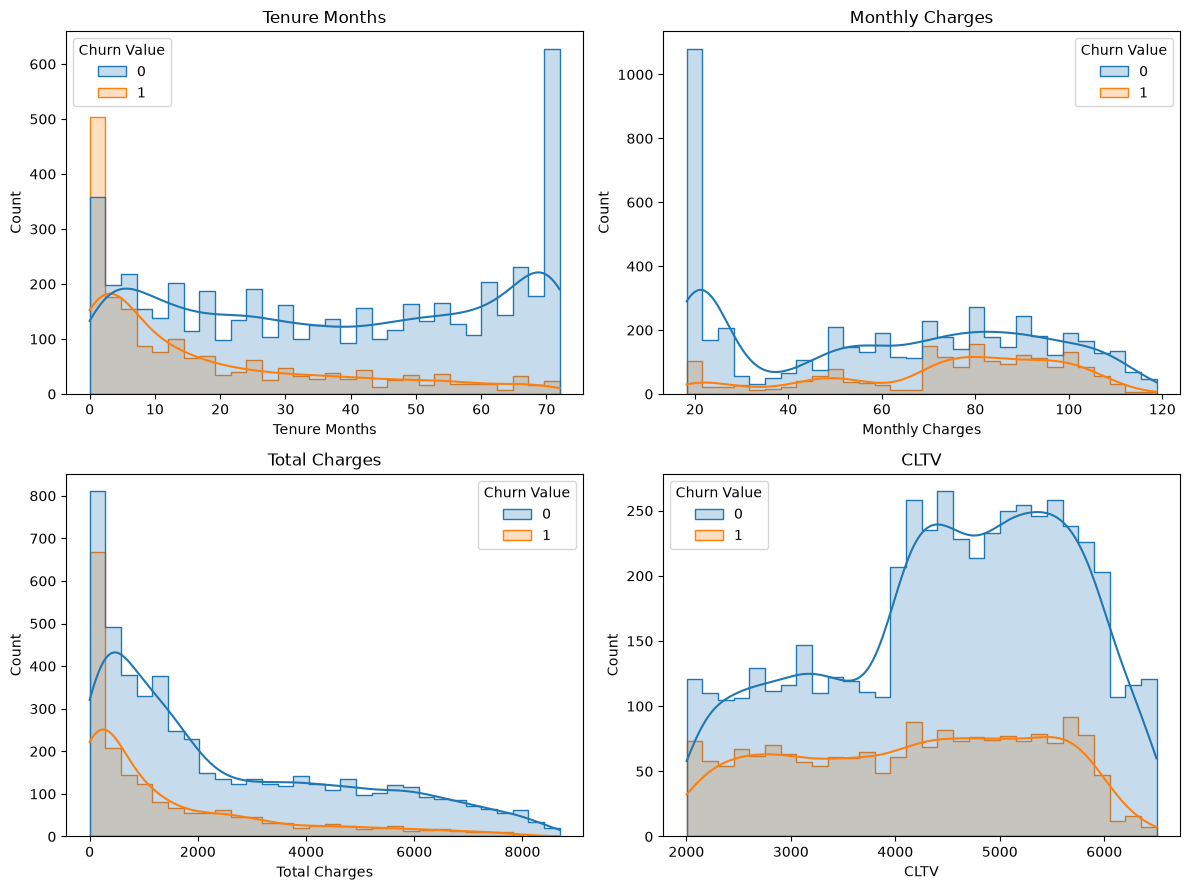

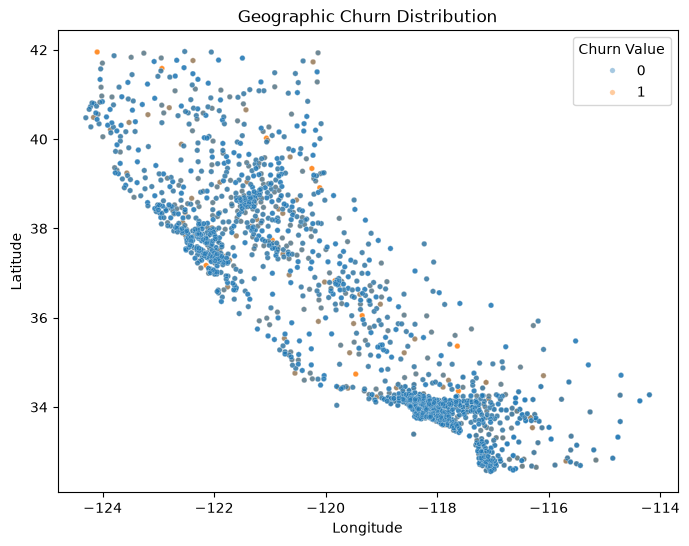

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(true_continuous):
    sns.histplot(data=df, x=col, hue='Churn Value', kde=True, ax=axes[i], bins=30, element='step')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Geo scatter — separate plot type since lat/long is spatial, not distributional
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Longitude', y='Latitude', hue='Churn Value', alpha=0.4, s=15)
plt.title('Geographic Churn Distribution')
plt.show()

In [17]:
# --- Numeric summary stats, reshaped into a clean table ---
numeric_summary = df.groupby('Churn Value')[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']].agg(['mean', 'median', 'std']).round(2)

# Flatten the multi-index columns and pivot into a readable format
summary_clean = numeric_summary.T.reset_index()
summary_clean.columns = ['Feature', 'Stat', 'Not Churned (0)', 'Churned (1)']
summary_clean = summary_clean.sort_values(['Feature', 'Stat'])

print(summary_clean.to_string(index=False))

        Feature   Stat  Not Churned (0)  Churned (1)
           CLTV   mean          4490.92      4149.41
           CLTV median          4620.00      4238.00
           CLTV    std          1167.70      1189.37
Monthly Charges   mean            61.27        74.44
Monthly Charges median            64.43        79.65
Monthly Charges    std            31.09        24.67
  Tenure Months   mean            37.57        17.98
  Tenure Months median            38.00        10.00
  Tenure Months    std            24.11        19.53
  Total Charges   mean          2549.91      1531.80
  Total Charges median          1679.52       703.55
  Total Charges    std          2329.95      1890.82


### Numeric features — correlation, multicollinearity, outliers, and bivariate structure

`Total Charges` is roughly `Tenure Months × Monthly Charges`, so expect strong collinearity. Also
check outliers and how the two main continuous drivers separate churners before feeding them to a model.

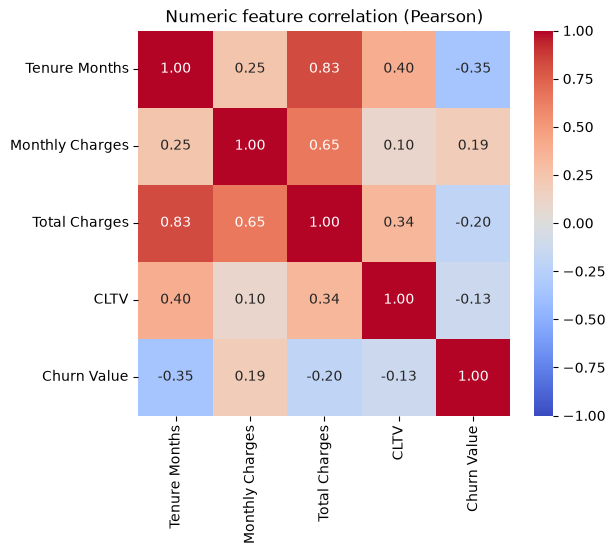

corr(Total Charges, Tenure * Monthly): 1.0


In [18]:
corr_cols = true_continuous + ['Churn Value']

plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Numeric feature correlation (Pearson)')
plt.show()

# Explicit multicollinearity check
implied_total = df['Tenure Months'] * df['Monthly Charges']
print("corr(Total Charges, Tenure * Monthly):", round(df['Total Charges'].corr(implied_total), 3))

**Observation:** `Total Charges` is almost perfectly explained by `Tenure Months × Monthly Charges`
(r ≈ 0.99) and is strongly correlated with `Tenure Months` alone — redundant for a linear model,
keep only one. `CLTV` correlates only weakly with churn, reinforcing that it adds little as a feature.
`Tenure Months` (negative) and `Monthly Charges` (positive) are the two useful continuous signals.

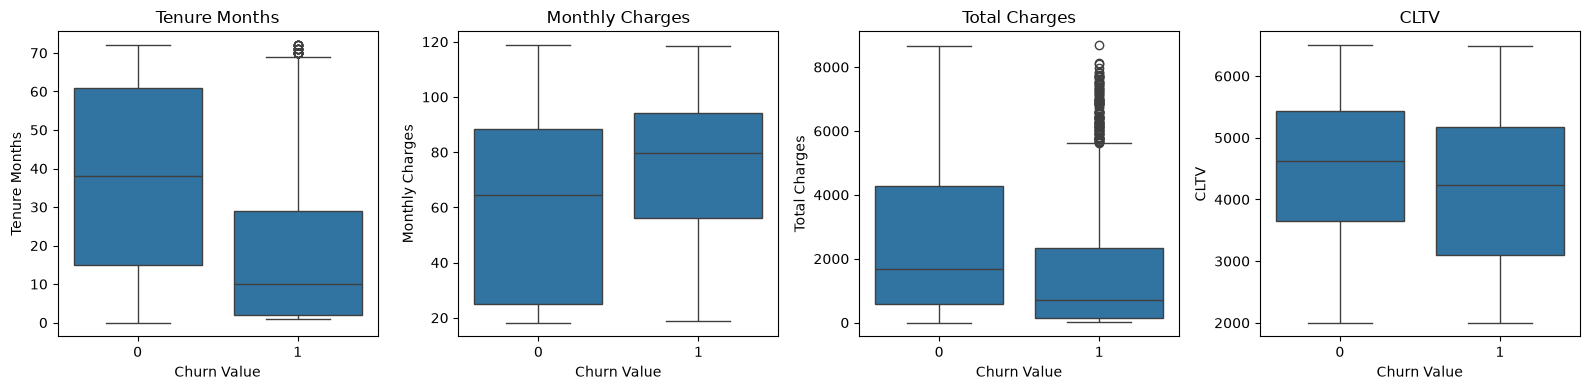

Tenure Months    0 IQR outliers
Monthly Charges  0 IQR outliers
Total Charges    0 IQR outliers
CLTV             0 IQR outliers


In [19]:
# Outliers — boxplot per continuous feature, split by churn
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, true_continuous):
    sns.boxplot(data=df, x='Churn Value', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# IQR-rule outlier count per feature
for col in true_continuous:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col:<16} {outliers} IQR outliers")

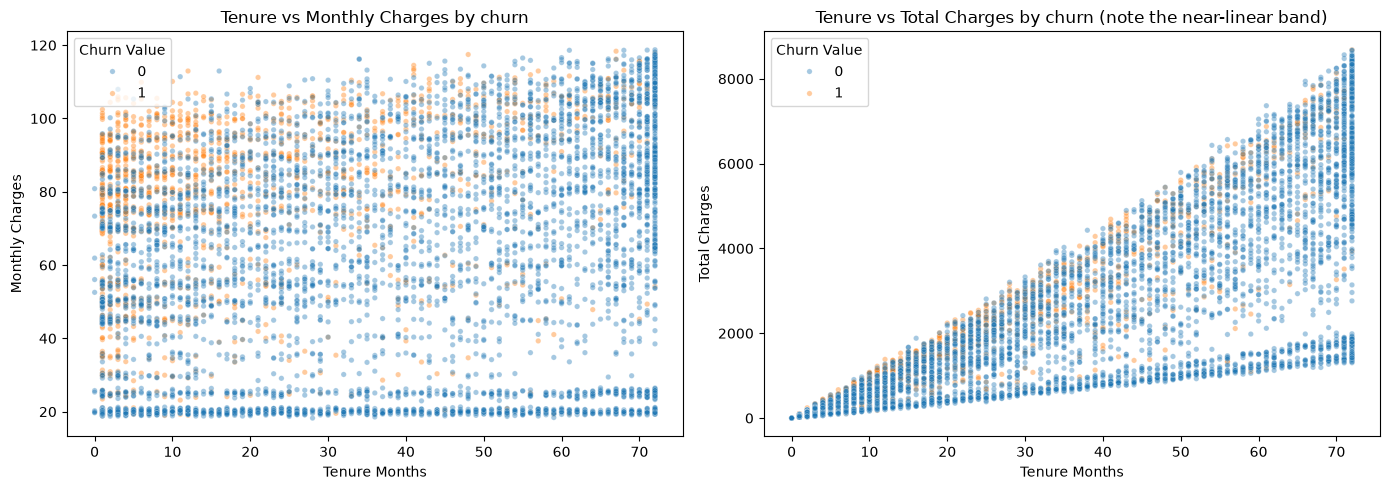

In [20]:
# Bivariate: how the two main continuous drivers interact with churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='Tenure Months', y='Monthly Charges', hue='Churn Value',
                alpha=0.4, s=15, ax=axes[0])
axes[0].set_title('Tenure vs Monthly Charges by churn')
sns.scatterplot(data=df, x='Tenure Months', y='Total Charges', hue='Churn Value',
                alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('Tenure vs Total Charges by churn (note the near-linear band)')
plt.tight_layout()
plt.show()

In [21]:
# Mann-Whitney U — non-parametric, since none of these are normally distributed
stayed = df[df['Churn Value'] == 0]
churned = df[df['Churn Value'] == 1]
for col in true_continuous:
    _, p_value = stats.mannwhitneyu(stayed[col], churned[col])
    print(f"{col:<16} Mann-Whitney U p-value = {p_value:.3e}")

# Churn rate by tenure bucket — shows how front-loaded churn is
tenure_bucket = pd.cut(df['Tenure Months'], bins=[0, 6, 12, 24, 48, 72], include_lowest=True)
print("\nChurn rate by tenure bucket:")
print(df.groupby(tenure_bucket, observed=True)['Churn Value'].agg(['mean', 'count']).round(3))

Tenure Months    Mann-Whitney U p-value = 2.420e-208
Monthly Charges  Mann-Whitney U p-value = 3.312e-54
Total Charges    Mann-Whitney U p-value = 5.685e-83
CLTV             Mann-Whitney U p-value = 3.244e-25

Churn rate by tenure bucket:
                mean  count
Tenure Months              
(-0.001, 6.0]  0.529   1481
(6.0, 12.0]    0.359    705
(12.0, 24.0]   0.287   1024
(24.0, 48.0]   0.204   1594
(48.0, 72.0]   0.095   2239


### Fiber optic churn — price, not tech quality?

The count-plot observations flagged that Fiber optic churns more than DSL "despite being the better
tech" and said to cross-check against Monthly Charges. Doing that here.

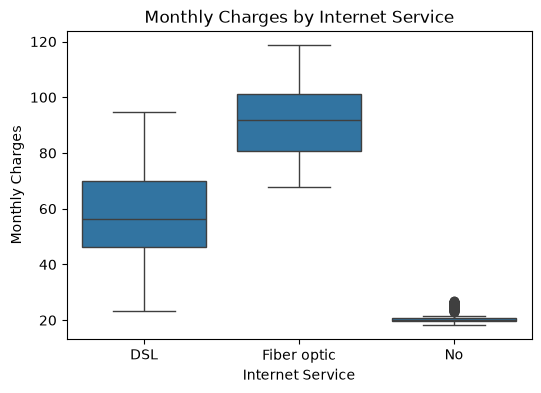

                  Monthly Charges  Churn Value
Internet Service                              
DSL                         58.10         0.19
Fiber optic                 91.50         0.42
No                          21.08         0.07


In [22]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Internet Service', y='Monthly Charges')
plt.title('Monthly Charges by Internet Service')
plt.show()

print(df.groupby('Internet Service')[['Monthly Charges', 'Churn Value']].mean().round(2))

### High-cardinality columns — City, Zip Code, Lat Long

These were skipped by the count-plot step. Quick look at whether `City` carries usable signal, and
confirmation that `Lat Long` is redundant with `Latitude` / `Longitude`.

In [23]:
MIN_CITY_CUSTOMERS = 50

print("City unique values    :", df['City'].nunique())
print("Zip Code unique values:", df['Zip Code'].nunique())

city_churn = df.groupby('City')['Churn Value'].agg(['mean', 'count'])
city_churn = city_churn[city_churn['count'] >= MIN_CITY_CUSTOMERS].sort_values('mean', ascending=False)
print(f"\nCities with >= {MIN_CITY_CUSTOMERS} customers, by churn rate (top / bottom 5):")
print(pd.concat([city_churn.head(5), city_churn.tail(5)]).round(3))

# Lat Long is just Latitude + Longitude concatenated — confirm it carries no new information
rebuilt = df['Latitude'].round(6).astype(str) + ', ' + df['Longitude'].round(6).astype(str)
print("\nLat Long rows reconstructable from Latitude/Longitude:",
      f"{(rebuilt == df['Lat Long']).mean():.1%} (rest differ only in float formatting)")

City unique values    : 1129
Zip Code unique values: 1652

Cities with >= 50 customers, by churn rate (top / bottom 5):
                mean  count
City                       
San Diego      0.333    150
San Francisco  0.298    104
Los Angeles    0.295    305
San Jose       0.259    112
Fresno         0.250     64
San Jose       0.259    112
Fresno         0.250     64
Long Beach     0.250     60
Oakland        0.250     52
Sacramento     0.241    108

Lat Long rows reconstructable from Latitude/Longitude: 100.0% (rest differ only in float formatting)


**Observation:** Only ~10 of 1,129 cities have >= 50 customers. Across those the churn rate spans
24-33% against a 26.5% base rate — a ~9pt spread, and San Diego's high value (33% on 150 customers)
is under 2 standard errors from the mean, i.e. not clearly signal. The remaining ~1,120 cities
average ~4 customers each and are noise as individual categories; `Zip Code` (1,652 levels) is worse,
and as a raw integer it is meaningless (90003 vs 90005 is not a real distance). `Lat Long` is 100%
reconstructable from `Latitude` / `Longitude`.

**Decision:** Drop `City`, `Zip Code`, `Lat Long`. Keep `Latitude` + `Longitude` as two numeric
features so a tree model can still isolate geographic pockets without the cardinality blow-up.
Optionally test a CV-fold target-encoded `City` as a separate experiment and compare PR-AUC — the
flat spread above predicts it will not help.

## Data cleaning pipeline — summary of steps

Consolidated from the analysis above. This is the spec for the preprocessing pipeline the AIM asked for.

**1. Drop columns**
- Zero variance: `Count`, `Country`, `State`
- Leakage (post-churn information): `Churn Label`, `Churn Score`, `Churn Reason`
- Redundant / near-unique: `Lat Long` (100% reconstructable from `Latitude`/`Longitude`), `Zip Code` (1,652 levels, meaningless as an integer), `City` (1,129 levels, only ~10 with >= 50 customers, ~9pt churn spread among those — drop from v1; optional CV-fold target-encoding experiment)
- `CustomerID`: identifier
- `CLTV`: vendor-derived score, weak churn correlation and possible leakage — drop unless justified

**2. Keep as numeric features**
- `Latitude`, `Longitude` — lets a tree model isolate geographic pockets without cardinality cost (drop them for a purely linear model, or k-means cluster them into regions first)

**3. Fix dtypes**
- `Total Charges`: `to_numeric(errors='coerce')`; the 11 NaNs are tenure-0 signups → fill with `0`

**4. Collapse redundant categories** (structurally determined, not independent signal)
- 6 add-on columns (`Online Security` … `Streaming Movies`): `"No internet service"` → `"No"`
- `Multiple Lines`: `"No phone service"` → `"No"`
- Re-check `Streaming TV` / `Streaming Movies` after this — their chi-square rank is inflated by the `"No internet service"` bucket; Yes-vs-No spread alone is ~3pt (weak)

**5. Encode**
- Binary Yes/No → 0/1
- `Contract` is ordinal: Month-to-month < One year < Two year
- One-hot: `Internet Service`, `Payment Method`, `Gender`

**6. Scale** (linear / distance-based models only)
- Standardize `Tenure Months`, `Monthly Charges`, `Total Charges`, `Latitude`, `Longitude`

**7. Multicollinearity**
- `Total Charges` ≈ `Tenure Months` × `Monthly Charges` — keep only one of `Total Charges` / `Tenure Months` for linear models (trees unaffected)

**8. Target & split**
- Target = `Churn Value` (~26.5% positive)
- Stratified train/test split; use `class_weight='balanced'` or resampling; evaluate with PR-AUC / recall, not accuracy

**9. Expected feature importance (from EDA + chi-square / Cramér's V)**
- Strong: `Contract`, `Tenure Months`, `Online Security`, `Tech Support`, `Internet Service`, `Payment Method`, `Online Backup`, `Device Protection`, `Monthly Charges`, `Dependents`
- Moderate: `Paperless Billing`, `Senior Citizen`, `Partner`
- Weak / drop candidates: `Gender`, `Phone Service`, `Multiple Lines`, `Streaming TV`, `Streaming Movies`